In [111]:
!pip install langgraph langchain langchain_community langchain_huggingface

### 1) Non-LLM Parallal Workflow

In [112]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [113]:
class CricketState(TypedDict):
  runs : int
  balls: int
  fours: int
  sixes: int

  strike_rate: float
  boundaryPercent: float
  ballsPerBoundary: float

  summary: str

In [114]:
def calculateSR(state: CricketState):
  runs = state['runs']
  balls = state['balls']
  strike_rate = (runs/balls)*100
  return {'strike_rate': strike_rate}

In [115]:
def calculateBP(state: CricketState):
  fours = state['fours']
  sixes = state['sixes']
  runs = state['runs']
  boundaryPercent = (((fours*4)+(sixes*6))/runs)*100
  return {'boundaryPercent' : boundaryPercent}


In [116]:
def calculateBPB(state: CricketState):
  balls = state['balls']
  fours = state['fours']
  sixes = state['sixes']
  ballsPerBoundary = balls / (fours + sixes)
  return {'ballsPerBoundary' : ballsPerBoundary}

In [117]:
def summary(state: CricketState) -> CricketState:
  summary = f"""
  Strike Rate: {state['strike_rate']} \n
  Boundary Percent: {state['boundaryPercent']} \n
  Balls Per Boundary: {state['ballsPerBoundary']}
  """
  state['summary'] = summary
  return state

In [118]:
cricketGraph = StateGraph(CricketState)
cricketGraph.add_node('calculateSR', calculateSR)
cricketGraph.add_node('calculateBP', calculateBP)
cricketGraph.add_node('calculateBPB', calculateBPB)
cricketGraph.add_node('summary', summary)

In [119]:
cricketGraph.add_edge(START, 'calculateSR')
cricketGraph.add_edge(START, 'calculateBP')
cricketGraph.add_edge(START, 'calculateBPB')

cricketGraph.add_edge('calculateSR', 'summary')
cricketGraph.add_edge('calculateBP', 'summary')
cricketGraph.add_edge('calculateBPB', 'summary')

cricketGraph.add_edge('summary', END)

In [120]:
cricketWorkflow = cricketGraph.compile()

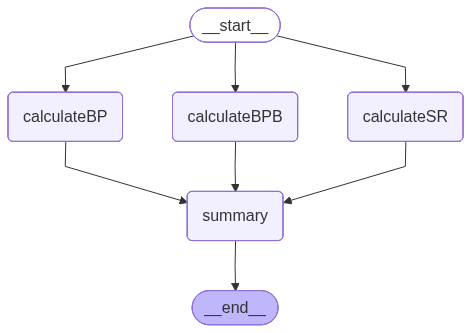

In [121]:
from IPython.display import Image
Image(cricketWorkflow.get_graph().draw_mermaid_png())

In [122]:
cricketWorkflow.invoke({'runs': 100, 'balls': 50, 'fours': 10, 'sixes': 6})

{'runs': 100,
 'balls': 50,
 'fours': 10,
 'sixes': 6,
 'strike_rate': 200.0,
 'boundaryPercent': 76.0,
 'ballsPerBoundary': 3.125,
 'summary': '\n  Strike Rate: 200.0 \n\n  Boundary Percent: 76.0 \n\n  Balls Per Boundary: 3.125\n  '}

### 2) LLM Parallel Workflow

In [123]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [124]:
from pydantic import BaseModel, Field

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [126]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [127]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [128]:
from langchain_core.output_parsers import PydanticOutputParser
class EvaluationSchema(BaseModel):
  feedback: str = Field(description= 'Detailed Feedback for the Essay')
  score: int = Field(description = 'Score out of 10', ge=0, le = 10)

In [129]:
essay1 = "Animals are integral to Earth's biosphere, serving as vital ecological, economic, and emotional pillars. They maintain environmental balance and sustain human livelihoods. However, this connection brings deep ethical responsibilities to protect these sentient beings from habitat loss, poaching, and exploitation.The Ecological BackboneEvery animal, from apex predators to microscopic organisms, occupies a specific niche that drives the ecosystem. Wild animals maintain the balance of nature through natural food chains. Herbivores control plant overgrowth, predators manage herbivore populations to prevent habitat destruction, and insects act as primary pollinators. Without this interconnected network, the global biosphere would collapse.Economic and Practical ContributionsThroughout history, human survival and economic progress have been intertwined with the animal kingdom:Agriculture and Food: Domesticated livestock like cattle, sheep, and poultry provide essential protein, dairy, and wool.Medicine and Research: Animal models are foundational for biomedical research, vaccine development, and pharmaceutical testing.Labor and Assistance: Animals like dogs assist in law enforcement, herding, and guiding the visually impaired, while draft animals support agricultural communities.Emotional and Companionship BondBeyond their practical utility, animals provide deep emotional and psychological value to humans. Domestic pets such as dogs and cats offer companionship and reduce human loneliness and stress. Interacting with animals has been shown to boost a child's positive emotional development and increase adult socialization.Our Ethical ResponsibilityDespite their immense value, animals globally face unprecedented threats. Human activities such as deforestation, environmental pollution, poaching, and the use of animals in cruel entertainment drastically diminish wildlife populations and push species toward extinction. Addressing these issues requires strict wildlife protection laws and ethical treatment standards. Organizations like PETA lead advocacy for ending systemic animal abuse, while World Wildlife Fund (WWF) works to conserve endangered species and their natural habitats.ConclusionAnimals are not merely commodities or resources; they are essential co-inhabitants of Earth. The survival and well-being of the human race rely directly on the health of the animal kingdom. Protecting them is a fundamental moral duty required to maintain the harmony of our planet"

In [130]:
import operator
from typing import Annotated

In [131]:
class EssayState(TypedDict):
  essay:str
  language_feedback:str
  clarity_feedback : str
  analysis_feedback : str
  overall_feedback : str

  individual_scores: Annotated[list[int], operator.add] # Reducer Function
  avg_score : float

In [132]:
def evaluateLanguage(state: EssayState):
    essay = state['essay']

    pydanticParser = PydanticOutputParser(pydantic_object=EvaluationSchema)
    prompt = PromptTemplate(
        template="""
        Evaluate the language quality of the following essay and provide feedback and a score out of 10.
        {format_instructions}
        Essay:
        {essay}
        """,
        input_variables=["essay"],
        partial_variables={
            "format_instructions":
            pydanticParser.get_format_instructions()
        }
    )

    chain = prompt | model | pydanticParser
    response = chain.invoke({"essay": essay})

    return {
        "language_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [133]:
def evaluateAnalysis(state: EssayState):
    essay = state['essay']

    pydanticParser = PydanticOutputParser(pydantic_object=EvaluationSchema)
    prompt = PromptTemplate(
        template="""
        Evaluate the depth of analysis of the following essay and provide feedback and a score out of 10.
        {format_instructions}
        Essay:
        {essay}
        """,
        input_variables=["essay"],
        partial_variables={
            "format_instructions":
            pydanticParser.get_format_instructions()
        }
    )

    chain = prompt | model | pydanticParser
    response = chain.invoke({"essay": essay})

    return {
        "analysis_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [134]:
def evaluateThought(state: EssayState):
    essay = state['essay']

    pydanticParser = PydanticOutputParser(pydantic_object=EvaluationSchema)
    prompt = PromptTemplate(
        template="""
        Evaluate the clarity of thought of the following essay and provide feedback and a score out of 10.
        {format_instructions}
        Essay:
        {essay}
        """,
        input_variables=["essay"],
        partial_variables={
            "format_instructions":
            pydanticParser.get_format_instructions()
        }
    )

    chain = prompt | model | pydanticParser
    response = chain.invoke({"essay": essay})

    return {
        "clarity_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [138]:
def finalEvaluation(state: EssayState):

    language_feedback = state["language_feedback"]
    clarity_feedback = state["clarity_feedback"]
    analysis_feedback = state["analysis_feedback"]

    prompt = PromptTemplate(
        template="""
Based on the following feedbacks, create a concise overall feedback.

Language Feedback:
{language_feedback}

Depth of Analysis Feedback:
{analysis_feedback}

Clarity of Thought Feedback:
{clarity_feedback}
""",
        input_variables=[
            "language_feedback",
            "analysis_feedback",
            "clarity_feedback"
        ]
    )
    chain = prompt | model | StrOutputParser()
    overall_feedback = chain.invoke({
        "language_feedback": language_feedback,
        "analysis_feedback": analysis_feedback,
        "clarity_feedback": clarity_feedback
    })

    avg_score = sum(state["individual_scores"]) / len(state["individual_scores"])
    return {"overall_feedback": overall_feedback, "avg_score": avg_score}


In [140]:
graph = StateGraph(EssayState)
graph.add_node('evaluateLanguage', evaluateLanguage)
graph.add_node('evaluateAnalysis', evaluateAnalysis)
graph.add_node('evaluateThought', evaluateThought)
graph.add_node('finalEvalauation', finalEvaluation)

graph.add_edge(START, 'evaluateLanguage')
graph.add_edge(START, 'evaluateAnalysis')
graph.add_edge(START, 'evaluateThought')

graph.add_edge('evaluateLanguage', 'finalEvalauation')
graph.add_edge('evaluateAnalysis', 'finalEvalauation')
graph.add_edge('evaluateThought', 'finalEvalauation')

graph.add_edge('finalEvalauation', END)

In [141]:
EssayWorkflow = graph.compile()

In [142]:
EssayWorkflow.invoke({'essay': essay1})

{'essay': "Animals are integral to Earth's biosphere, serving as vital ecological, economic, and emotional pillars. They maintain environmental balance and sustain human livelihoods. However, this connection brings deep ethical responsibilities to protect these sentient beings from habitat loss, poaching, and exploitation.The Ecological BackboneEvery animal, from apex predators to microscopic organisms, occupies a specific niche that drives the ecosystem. Wild animals maintain the balance of nature through natural food chains. Herbivores control plant overgrowth, predators manage herbivore populations to prevent habitat destruction, and insects act as primary pollinators. Without this interconnected network, the global biosphere would collapse.Economic and Practical ContributionsThroughout history, human survival and economic progress have been intertwined with the animal kingdom:Agriculture and Food: Domesticated livestock like cattle, sheep, and poultry provide essential protein, dai

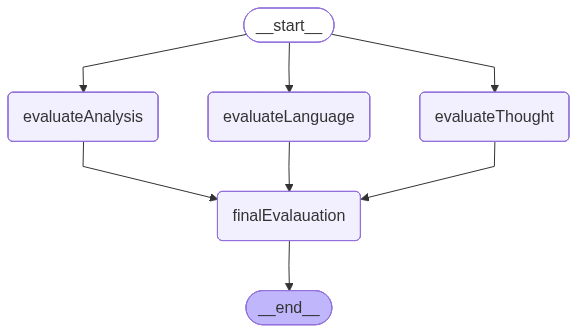

In [143]:
from IPython.display import Image
Image(EssayWorkflow.get_graph().draw_mermaid_png())